In [24]:
# 1. Force install the specific version Colab wants
!pip install pandas==2.2.2
!pip install numpy==1.25.2
!pip install seaborn
!pip install matplotlib

# 2. Upgrade the other libraries, but leave pandas OUT of this line
!pip install -qU langgraph langchain-groq

  Using cached numpy-1.25.2.tar.gz (10.8 MB)
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


#import the API key


In [6]:
from google.colab import files
import pandas as pd
import numpy as np

uploaded = files.upload()
df = pd.read_csv("FOOD WASTAGE.csv")
print(f"Shape of the dataset: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


Saving FOOD WASTAGE.csv to FOOD WASTAGE (2).csv
Shape of the dataset: 69 rows, 11 columns


,Type of Food,Number of Guests,Event Type,Quantity of Food,Storage Conditions,Purchase History,Seasonality,Preparation Method,Geographical Location,Pricing,Wastage Food Amount
0,Meat,310,Corporate,450,Refrigerated,Regular,All Seasons,Buffet,Urban,Low,$25
1,Meat,400,Birthday,500,Room Temperature,Regular,Winter,Buffet,Suburban,High,$40
2,Vegetables,302,Birthday,371,Refrigerated,Regular,Summer,Buffet,Suburban,Low,$27
3,Meat,491,Birthday,497,Refrigerated,Regular,All Seasons,Finger Food,Rural,High,$32
4,Meat,300,Corporate,400,Refrigerated,Regular,Winter,Finger Food,Urban,Moderate,$25


Data Understanding

In [7]:
print("Column data types:\n")
print(df.dtypes)

print("\n" + "="*50)
print("Basic info:")
df.info()


Column data types:

Type of Food             object
Number of Guests          int64
Event Type               object
Quantity of Food          int64
Storage Conditions       object
Purchase History         object
Seasonality              object
Preparation Method       object
Geographical Location    object
Pricing                  object
Wastage Food Amount      object
dtype: object

Basic info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69 entries, 0 to 68
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Type of Food           69 non-null     object
 1   Number of Guests       69 non-null     int64 
 2   Event Type             69 non-null     object
 3   Quantity of Food       69 non-null     int64 
 4   Storage Conditions     69 non-null     object
 5   Purchase History       69 non-null     object
 6   Seasonality            69 non-null     object
 7   Preparation Method     69 non-null

In [8]:
# Summary statistics for numeric columns
df.describe(include='number')

# Explore categorical columns: list unique values for each
categorical_cols = ['Type of Food', 'Event Type', 'Storage Conditions',
                     'Purchase History', 'Seasonality', 'Preparation Method',
                     'Geographical Location', 'Pricing']

for col in categorical_cols:
    print(f"'{col}' -> {df[col].unique()}")
    print()


'Type of Food' -> ['Meat' 'Vegetables' 'Fruits' 'Baked Goods' 'Dairy Products']

'Event Type' -> ['Corporate' 'Birthday' 'Wedding' 'Social Gathering']

'Storage Conditions' -> ['Refrigerated' 'Room Temperature']

'Purchase History' -> ['Regular' 'Occasional']

'Seasonality' -> ['All Seasons' 'Winter' 'Summer']

'Preparation Method' -> ['Buffet' 'Finger Food' 'Sit-down Dinner']

'Geographical Location' -> ['Urban' 'Suburban' 'Rural']

'Pricing' -> ['Low' 'High' 'Moderate']



In [9]:
# Check for missing values in every column
missing_summary = df.isnull().sum()
print("Missing values per column:\n")
print(missing_summary)

if missing_summary.sum() == 0:
    print("\nNo missing values found — dataset is clean on that front.")
else:
    print("\nSome missing values found — we'll handle these in Data Cleaning.")


Missing values per column:

Type of Food             0
Number of Guests         0
Event Type               0
Quantity of Food         0
Storage Conditions       0
Purchase History         0
Seasonality              0
Preparation Method       0
Geographical Location    0
Pricing                  0
Wastage Food Amount      0
dtype: int64

No missing values found — dataset is clean on that front.


Data Cleaning

In [18]:
# Work on a copy so the original raw dataframe stays untouched for reference
df_clean = df.copy()

# 1. Clean 'Wastage Food Amount': remove '$' and convert to float
df_clean['Wastage Food Amount'] = (
    df_clean['Wastage Food Amount']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.strip()
    .astype(float)
)

print("Wastage Food Amount cleaned. Sample values:")
print(df_clean['Wastage Food Amount'].head())
print(f"\nData type now: {df_clean['Wastage Food Amount'].dtype}")

# 2. Strip stray whitespace from all text (categorical) columns
text_cols = df_clean.select_dtypes(include='object').columns
for col in text_cols:
    df_clean[col] = df_clean[col].str.strip()

print("Whitespace cleaned for columns:", list(text_cols))

# 3. Check for duplicate rows
duplicate_count = df_clean.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

if duplicate_count > 0:
    df_clean = df_clean.drop_duplicates().reset_index(drop=True)
    print("Duplicates removed.")
else:
    print("No duplicate rows found.")


# 4. Final check: confirm no missing values remain and data types are correct
print("Missing values after cleaning:")
print(df_clean.isnull().sum())

print("\nFinal data types:")
print(df_clean.dtypes)

print(f"\nFinal cleaned dataset shape: {df_clean.shape}")
df_clean.head()

Wastage Food Amount cleaned. Sample values:
0    25.0
1    40.0
2    27.0
3    32.0
4    25.0
Name: Wastage Food Amount, dtype: float64

Data type now: float64
Whitespace cleaned for columns: ['Type of Food', 'Event Type', 'Storage Conditions', 'Purchase History', 'Seasonality', 'Preparation Method', 'Geographical Location', 'Pricing']
Number of duplicate rows: 0
No duplicate rows found.
Missing values after cleaning:
Type of Food             0
Number of Guests         0
Event Type               0
Quantity of Food         0
Storage Conditions       0
Purchase History         0
Seasonality              0
Preparation Method       0
Geographical Location    0
Pricing                  0
Wastage Food Amount      0
dtype: int64

Final data types:
Type of Food              object
Number of Guests           int64
Event Type                object
Quantity of Food           int64
Storage Conditions        object
Purchase History          object
Seasonality               object
Preparation Method

,Type of Food,Number of Guests,Event Type,Quantity of Food,Storage Conditions,Purchase History,Seasonality,Preparation Method,Geographical Location,Pricing,Wastage Food Amount
0,Meat,310,Corporate,450,Refrigerated,Regular,All Seasons,Buffet,Urban,Low,25.0
1,Meat,400,Birthday,500,Room Temperature,Regular,Winter,Buffet,Suburban,High,40.0
2,Vegetables,302,Birthday,371,Refrigerated,Regular,Summer,Buffet,Suburban,Low,27.0
3,Meat,491,Birthday,497,Refrigerated,Regular,All Seasons,Finger Food,Rural,High,32.0
4,Meat,300,Corporate,400,Refrigerated,Regular,Winter,Finger Food,Urban,Moderate,25.0


Exploratory data analysis (EDA)

In [20]:
# Average wastage by Event Type
event_waste = df_clean.groupby('Event Type')['Wastage Food Amount'].mean().sort_values(ascending=False)
print("Average Wastage Food Amount by Event Type:\n")
print(event_waste)

# Average wastage by Type of Food
food_waste = df_clean.groupby('Type of Food')['Wastage Food Amount'].mean().sort_values(ascending=False)
print("Average Wastage Food Amount by Type of Food:\n")
print(food_waste)

# Average wastage by Seasonality
season_waste = df_clean.groupby('Seasonality')['Wastage Food Amount'].mean().sort_values(ascending=False)
print("Average Wastage Food Amount by Seasonality:\n")
print(season_waste)

# Correlation between numeric columns
numeric_cols = ['Number of Guests', 'Quantity of Food', 'Wastage Food Amount']
correlation_matrix = df_clean[numeric_cols].corr()
print("Correlation matrix (numeric columns):\n")
print(correlation_matrix)

Average Wastage Food Amount by Event Type:

Event Type
Wedding             32.125000
Birthday            28.523810
Corporate           26.869565
Social Gathering    22.444444
Name: Wastage Food Amount, dtype: float64
Average Wastage Food Amount by Type of Food:

Type of Food
Meat              29.00
Fruits            28.95
Baked Goods       27.50
Vegetables        24.00
Dairy Products    23.00
Name: Wastage Food Amount, dtype: float64
Average Wastage Food Amount by Seasonality:

Seasonality
Summer         29.608696
All Seasons    29.000000
Winter         26.266667
Name: Wastage Food Amount, dtype: float64
Correlation matrix (numeric columns):

                     Number of Guests  Quantity of Food  Wastage Food Amount
Number of Guests             1.000000          0.797693             0.650963
Quantity of Food             0.797693          1.000000             0.685262
Wastage Food Amount          0.650963          0.685262             1.000000


Data Visualization

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

/tmp/ipykernel_1487/1058054552.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=event_waste.index, y=event_waste.values, palette="viridis")


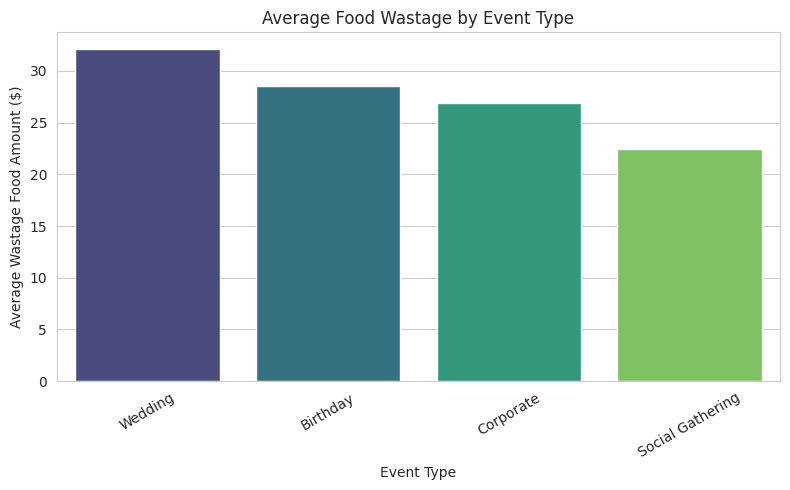

In [27]:
# 1. Food Waste by Event Type
plt.figure()
sns.barplot(x=event_waste.index, y=event_waste.values, palette="viridis")
plt.title("Average Food Wastage by Event Type")
plt.xlabel("Event Type")
plt.ylabel("Average Wastage Food Amount ($)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1487/1905544222.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=food_waste.index, y=food_waste.values, palette="magma")


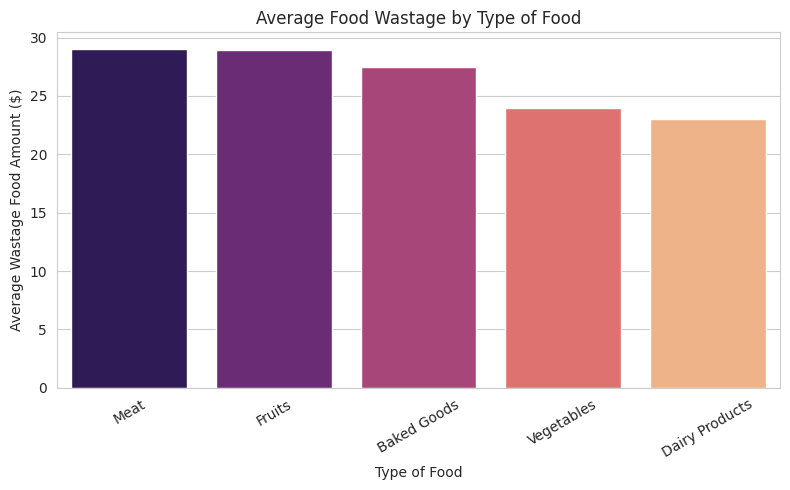

In [28]:
# 2. Food Waste by Food Type
plt.figure()
sns.barplot(x=food_waste.index, y=food_waste.values, palette="magma")
plt.title("Average Food Wastage by Type of Food")
plt.xlabel("Type of Food")
plt.ylabel("Average Wastage Food Amount ($)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


/tmp/ipykernel_1487/492244303.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=storage_waste.index, y=storage_waste.values, palette="crest")


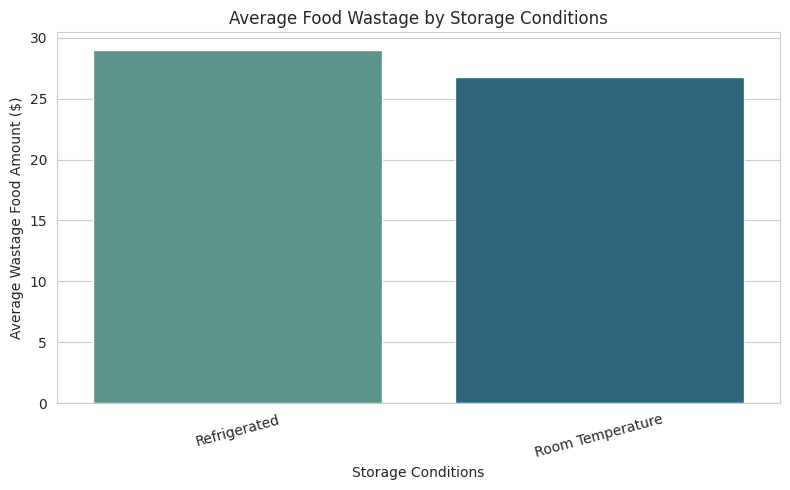

In [30]:
storage_waste = df_clean.groupby('Storage Conditions')['Wastage Food Amount'].mean().sort_values(ascending=False)

# 3. Food Waste by Storage Conditions
plt.figure()
sns.barplot(x=storage_waste.index, y=storage_waste.values, hue=storage_waste.index, palette="crest", legend=False)
plt.title("Average Food Wastage by Storage Conditions")
plt.xlabel("Storage Conditions")
plt.ylabel("Average Wastage Food Amount ($)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1487/3581741816.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=season_waste.index, y=season_waste.values, palette="flare")


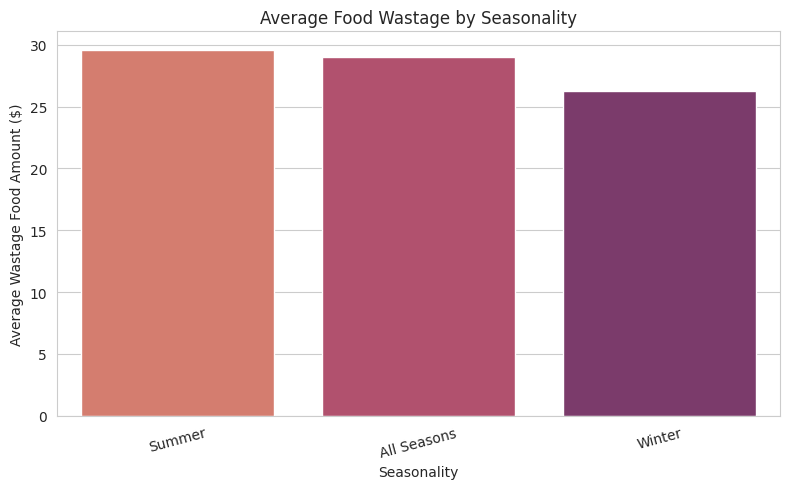

In [31]:
# 4. Food Waste by Seasonality
plt.figure()
sns.barplot(x=season_waste.index, y=season_waste.values, palette="flare")
plt.title("Average Food Wastage by Seasonality")
plt.xlabel("Seasonality")
plt.ylabel("Average Wastage Food Amount ($)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

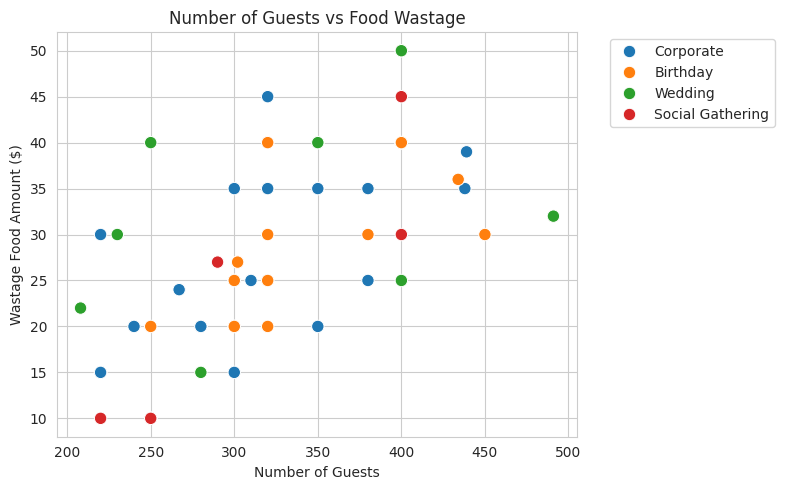

In [32]:
# 5. Guest Count vs Food Waste
plt.figure()
sns.scatterplot(data=df_clean, x='Number of Guests', y='Wastage Food Amount',
                 hue='Event Type', s=80)
plt.title("Number of Guests vs Food Wastage")
plt.xlabel("Number of Guests")
plt.ylabel("Wastage Food Amount ($)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


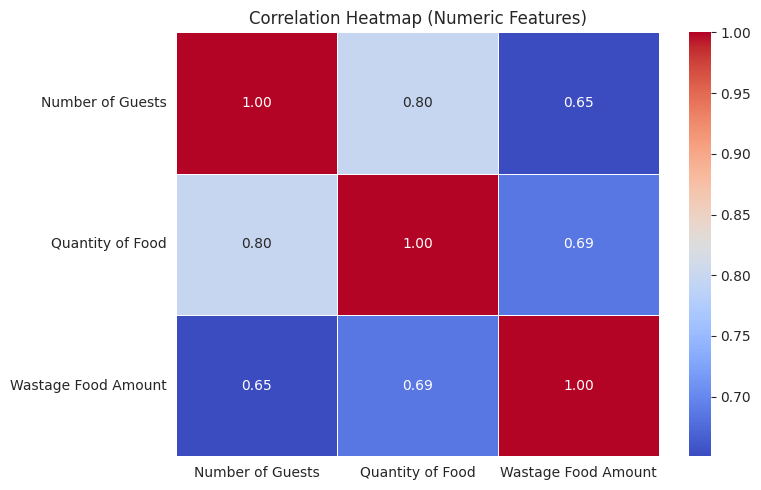

In [33]:
# 6. Correlation Heatmap
plt.figure()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()


Feature engineering

In [34]:
# Separate features (X) and target (y)
X = df_clean.drop(columns=['Wastage Food Amount'])
y = df_clean['Wastage Food Amount']

print("Feature columns:", list(X.columns))
print(f"\nTarget: 'Wastage Food Amount' — {len(y)} values")

# One-Hot Encode all categorical (text) columns
categorical_features = X.select_dtypes(include='object').columns.tolist()
print("Categorical features to encode:", categorical_features)

X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=True)

print(f"\nShape before encoding: {X.shape}")
print(f"Shape after encoding: {X_encoded.shape}")
X_encoded.head()

Feature columns: ['Type of Food', 'Number of Guests', 'Event Type', 'Quantity of Food', 'Storage Conditions', 'Purchase History', 'Seasonality', 'Preparation Method', 'Geographical Location', 'Pricing']

Target: 'Wastage Food Amount' — 69 values
Categorical features to encode: ['Type of Food', 'Event Type', 'Storage Conditions', 'Purchase History', 'Seasonality', 'Preparation Method', 'Geographical Location', 'Pricing']

Shape before encoding: (69, 10)
Shape after encoding: (69, 19)


,Number of Guests,Quantity of Food,Type of Food_Dairy Products,Type of Food_Fruits,Type of Food_Meat,Type of Food_Vegetables,Event Type_Corporate,Event Type_Social Gathering,Event Type_Wedding,Storage Conditions_Room Temperature,Purchase History_Regular,Seasonality_Summer,Seasonality_Winter,Preparation Method_Finger Food,Preparation Method_Sit-down Dinner,Geographical Location_Suburban,Geographical Location_Urban,Pricing_Low,Pricing_Moderate
0,310,450,False,False,True,False,True,False,False,False,True,False,False,False,False,False,True,True,False
1,400,500,False,False,True,False,False,False,False,True,True,False,True,False,False,True,False,False,False
2,302,371,False,False,False,True,False,False,False,False,True,True,False,False,False,True,False,True,False
3,491,497,False,False,True,False,False,False,False,False,True,False,False,True,False,False,False,False,False
4,300,400,False,False,True,False,True,False,False,False,True,False,True,True,False,False,True,False,True


ML model

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Test set size: {X_test.shape[0]} rows")

# Train the Random Forest Regressor (our primary model)
rf_model = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)

# Train a simple Linear Regression as a baseline for comparison
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print("Both models trained successfully.")


Training set size: 55 rows
Test set size: 14 rows
Both models trained successfully.


--- Random Forest Regressor ---
MAE  : 4.03
RMSE : 6.18
R2   : 0.502

--- Linear Regression (baseline) ---
MAE  : 3.54
RMSE : 4.65
R2   : 0.718



/tmp/ipykernel_1487/2203351079.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_importances.values, y=top_importances.index, palette="viridis")


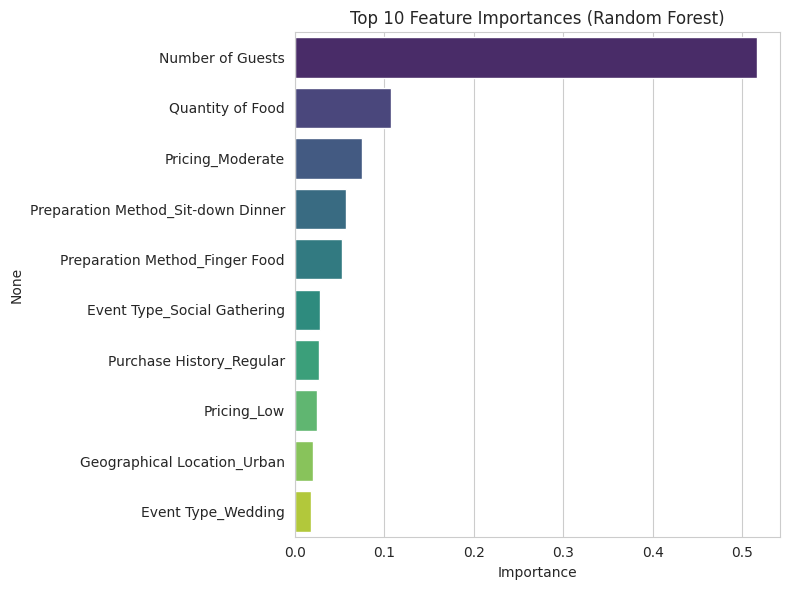

Top 10 most important features:

Number of Guests                      0.516244
Quantity of Food                      0.107349
Pricing_Moderate                      0.075106
Preparation Method_Sit-down Dinner    0.057272
Preparation Method_Finger Food        0.052805
Event Type_Social Gathering           0.028024
Purchase History_Regular              0.027648
Pricing_Low                           0.024751
Geographical Location_Urban           0.021037
Event Type_Wedding                    0.018801
dtype: float64


In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(model, X_test, y_test, name):
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    print(f"--- {name} ---")
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R2   : {r2:.3f}\n")
    return {"model": name, "MAE": mae, "RMSE": rmse, "R2": r2}

rf_results = evaluate_model(rf_model, X_test, y_test, "Random Forest Regressor")
lr_results = evaluate_model(lr_model, X_test, y_test, "Linear Regression (baseline)")

comparison_df = pd.DataFrame([rf_results, lr_results])
comparison_df

# Feature Importance from the Random Forest model
importances = pd.Series(rf_model.feature_importances_, index=X_encoded.columns)
top_importances = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 6))
sns.barplot(x=top_importances.values, y=top_importances.index, palette="viridis")
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print("Top 10 most important features:\n")
print(top_importances)




Food Wastage Prediction

In [39]:
def predict_wastage(new_event: dict, model=rf_model, reference_columns=X_encoded.columns):
    """
    Predicts food wastage amount for a new event.
    new_event: dict with keys matching the original feature columns, e.g.
        {
            'Type of Food': 'Meat', 'Number of Guests': 300, 'Event Type': 'Corporate',
            'Quantity of Food': 400, 'Storage Conditions': 'Refrigerated',
            'Purchase History': 'Regular', 'Seasonality': 'All Seasons',
            'Preparation Method': 'Buffet', 'Geographical Location': 'Urban', 'Pricing': 'Low'
        }
    """
    new_df = pd.DataFrame([new_event])
    new_encoded = pd.get_dummies(new_df)
    # Align columns with training data; any missing dummy columns become 0
    new_encoded = new_encoded.reindex(columns=reference_columns, fill_value=0)
    prediction = model.predict(new_encoded)[0]
    return round(prediction, 2)

# Example: a corporate buffet event
example_event = {
    'Type of Food': 'Meat', 'Number of Guests': 300, 'Event Type': 'Corporate',
    'Quantity of Food': 400, 'Storage Conditions': 'Refrigerated',
    'Purchase History': 'Regular', 'Seasonality': 'All Seasons','Preparation Method': 'Buffet', 'Geographical Location': 'Urban', 'Pricing': 'Low'
}

predicted_wastage = predict_wastage(example_event)
print(f"Predicted Wastage Food Amount for this event: ${predicted_wastage}")


Predicted Wastage Food Amount for this event: $23.25


AI-Based recommendation System

In [40]:
import getpass
import os
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage

# Enter your Groq API key when prompted (input is hidden for safety)
if "GROQ_API_KEY" not in os.environ:
    os.environ["GROQ_API_KEY"] = getpass.getpass("Enter your Groq API key: ")

llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0.3)
print("Groq LLM initialized.")

Enter your Groq API key: ··········
Groq LLM initialized.


In [41]:
#Step 1: Compute data-driven triggers (facts derived directly from the dataset)
# These thresholds compare a given event's category averages against the overall mean.
overall_mean_waste = df_clean['Wastage Food Amount'].mean()

def get_data_triggers(new_event: dict) -> list:
    """Returns a list of factual, data-backed observations relevant to this event."""
    triggers = []

    event_avg = event_waste.get(new_event['Event Type'], overall_mean_waste)
    if event_avg > overall_mean_waste:
        triggers.append(
            f"'{new_event['Event Type']}' events average ${event_avg:.2f} wastage, "
            f"above the overall average of ${overall_mean_waste:.2f}."
        )

    storage_avg = storage_waste.get(new_event['Storage Conditions'], overall_mean_waste)
    if storage_avg > overall_mean_waste:
        triggers.append(
            f"'{new_event['Storage Conditions']}' storage shows ${storage_avg:.2f} average wastage, "
            f"higher than the dataset average."
        )

    season_avg = season_waste.get(new_event['Seasonality'], overall_mean_waste)
    if season_avg > overall_mean_waste:
        triggers.append(
            f"Events during '{new_event['Seasonality']}' average ${season_avg:.2f} wastage."
        )

    if new_event.get('Preparation Method') == 'Buffet':
        triggers.append("Buffet-style preparation is generally associated with over-preparation risk.")

    if not triggers:
        triggers.append("No major risk factors detected — this event profile aligns with typical low-wastage patterns.")

    return triggers

# Test on our Section 9 example event
sample_triggers = get_data_triggers(example_event)
for t in sample_triggers:
    print("-", t)


- 'Refrigerated' storage shows $29.00 average wastage, higher than the dataset average.
- Events during 'All Seasons' average $29.00 wastage.
- Buffet-style preparation is generally associated with over-preparation risk.


In [42]:
RECOMMENDATION_SYSTEM_PROMPT = """You are a food service sustainability advisor for WasteWise AI.
You will be given: (1) a predicted food wastage amount for an event, and (2) a list of
data-driven observations about that event. Using ONLY the observations provided (do not
invent new facts or numbers), write 2-4 short, practical, business-oriented recommendations
to help reduce food wastage for this specific event. Be concise and actionable. Do not repeat
the raw numbers verbatim as your main point -- turn them into clear advice.
"""

def generate_recommendation(new_event: dict, predicted_wastage: float) -> str:
    triggers = get_data_triggers(new_event)
    triggers_text = "\n".join(f"- {t}" for t in triggers)

    user_message = (
        f"Predicted Wastage Food Amount: ${predicted_wastage}\n"
        f"Event details: {new_event}\n\n"
        f"Data-driven observations:\n{triggers_text}"
    )

    response = llm.invoke([
        SystemMessage(content=RECOMMENDATION_SYSTEM_PROMPT),
        HumanMessage(content=user_message)
    ])
    return response.content.strip()

# Generate a recommendation for our Section 9 example event
recommendation_text = generate_recommendation(example_event, predicted_wastage)
print("Predicted Wastage: $", predicted_wastage)
print("\nAI-Generated Recommendation:\n")
print(recommendation_text)


Predicted Wastage: $ 23.25

AI-Generated Recommendation:

Based on the data-driven observations, here are 3 practical recommendations to reduce food wastage for this corporate event:

1. **Optimize buffet portions**: Given the buffet-style preparation method, consider implementing portion control measures to minimize over-preparation and reduce waste.
2. **Review refrigerated storage practices**: As refrigerated storage is associated with higher average wastage, ensure that storage conditions are optimal and that food is handled and stored properly to prevent spoilage.
3. **Adjust food quantities**: With 400 quantities of food prepared for 300 guests, consider reducing the quantity of food prepared to avoid over-preparation and potential waste, especially given the higher average wastage associated with buffet-style events.


Deployment Preparation

In [43]:
import joblib

# 1. Save the trained model
joblib.dump(rf_model, "rf_model.pkl")

# 2. Save the reference columns (needed to align new inputs during prediction)
joblib.dump(list(X_encoded.columns), "reference_columns.pkl")

# 3. Save the category averages needed for the recommendation engine's triggers
recommendation_data = {
    "event_waste": event_waste.to_dict(),
    "storage_waste": storage_waste.to_dict(),
    "season_waste": season_waste.to_dict(),
    "overall_mean_waste": overall_mean_waste,
}
joblib.dump(recommendation_data, "recommendation_data.pkl")

print("Saved: rf_model.pkl, reference_columns.pkl, recommendation_data.pkl")


Saved: rf_model.pkl, reference_columns.pkl, recommendation_data.pkl


In [44]:
# In Colab, download these three files to your computer
from google.colab import files
files.download("rf_model.pkl")
files.download("reference_columns.pkl")
files.download("recommendation_data.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>